In [ ]:
# Install packages (if needed)
!pip install -q torch torchvision

# Imports
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE

from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 62.0 MB/s eta 0:00:00


In [ ]:
# Upload files using Colab's UI (if not already in environment)
from google.colab import files
uploaded = files.upload()

# Load CSV files
df_train = pd.read_csv('b_train.csv')
df_test = pd.read_csv('b_test.csv')

# Drop bidder_id for training
df_train = df_train.drop(columns=['bidder_id'])
df_train = df_train.fillna(0)
df_test = df_test.fillna(0)

# Separate features and target
X_train = df_train.drop(columns=['outcome'])
y_train = df_train['outcome']

# Keep test bidder_id for submission
X_test = df_test.drop(columns=['bidder_id'])


Saving b_test.csv to b_test.csv
Saving b_train.csv to b_train.csv


In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

X_train = X_train_resampled
y_train = y_train_resampled

In [ ]:
# Convert to tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

# Create Dataset and DataLoader
dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_size = int(0.85 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
# Define FNN model (A)
class BotPredictor(nn.Module):
    def __init__(self, input_dim, hidden_size):
        super(BotPredictor, self).__init__()

        self.hidden_size = hidden_size

        #  <> net
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_size//2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size//2, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(),
            nn.Linear(hidden_size//2, 1)
        )

    def forward(self, x):
        return self.net(x)

# Initialize model
model = BotPredictor(X_train.shape[1], 1024)

In [ ]:
# Loss function with class weighting
pos_weight = torch.tensor([len(y_train) / sum(y_train) - 1])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimizer and learning rate scheduler
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.8)

In [ ]:
# Training loop
epochs = 100

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    val_preds = []
    val_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_preds.append(torch.sigmoid(outputs).cpu().numpy())
            val_labels.append(labels.cpu().numpy())
    val_loss /= len(val_loader)

    val_preds = np.concatenate(val_preds).ravel()
    val_labels = np.concatenate(val_labels).ravel()
    val_binary_preds = (val_preds > 0.5).astype(int)

    # Metrics
    val_auc = roc_auc_score(val_labels, val_preds) if len(np.unique(val_labels)) > 1 else 0.5
    val_f1 = f1_score(val_labels, val_binary_preds)

    scheduler.step()

    if epoch % 10 == 0 or epoch == 99:
        print(f"epoch {epoch:3d} | train Loss: {train_loss:.4f} | val Loss: {val_loss:.4f} | val AUC: {val_auc:.4f} | val F1: {val_f1:.4f}")


epoch   0 | train Loss: 2568.6359 | val Loss: 1126.3814 | val AUC: 0.8229 | val F1: 0.8206
epoch  10 | train Loss: 0.9242 | val Loss: 0.7048 | val AUC: 0.5418 | val F1: 0.6874
epoch  20 | train Loss: 0.6135 | val Loss: 0.7105 | val AUC: 0.5510 | val F1: 0.6913
epoch  30 | train Loss: 0.5025 | val Loss: 0.4756 | val AUC: 0.8330 | val F1: 0.8343
epoch  40 | train Loss: 0.4493 | val Loss: 0.4541 | val AUC: 0.8316 | val F1: 0.8321
epoch  50 | train Loss: 0.4409 | val Loss: 0.4573 | val AUC: 0.8447 | val F1: 0.8326
epoch  60 | train Loss: 0.4842 | val Loss: 0.4551 | val AUC: 0.8420 | val F1: 0.8204
epoch  70 | train Loss: 0.4259 | val Loss: 0.4157 | val AUC: 0.8550 | val F1: 0.8589
epoch  80 | train Loss: 0.4012 | val Loss: 0.3998 | val AUC: 0.8750 | val F1: 0.8593
epoch  90 | train Loss: 0.3811 | val Loss: 0.4007 | val AUC: 0.8799 | val F1: 0.8545
epoch  99 | train Loss: 0.3699 | val Loss: 0.4307 | val AUC: 0.8871 | val F1: 0.8567


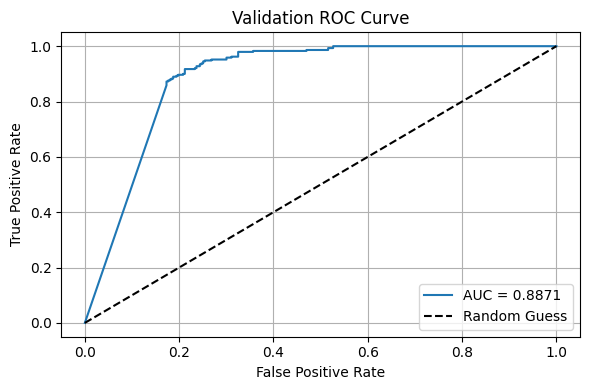

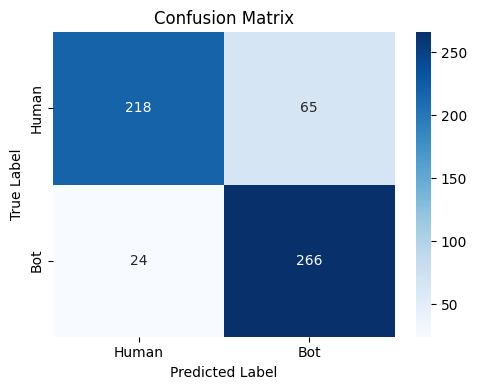

In [ ]:
# ✅ Visualize Final AUC-ROC Curve
fpr, tpr, _ = roc_curve(val_labels, val_preds)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {val_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("\n")

# ✅ Visualize Confusion Matrix
cm = confusion_matrix(val_labels, val_binary_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Human', 'Bot'], yticklabels=['Human', 'Bot'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# ✅ Final printed summary
print("\n📊 Final Evaluation on Validation Set:")
print(f"AUC-ROC: {val_auc:.4f}")
print(f"F1-Score: {val_f1:.4f}")


📊 Final Evaluation on Validation Set:
AUC-ROC: 0.8871
F1-Score: 0.8567


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Run final validation
model.eval()
val_preds = []
val_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        val_preds.append(torch.sigmoid(outputs).cpu().numpy())
        val_labels.append(labels.cpu().numpy())

val_preds = np.concatenate(val_preds).ravel()
val_labels = np.concatenate(val_labels).ravel()
val_binary = (val_preds > 0.5).astype(int)

final_auc = roc_auc_score(val_labels, val_preds)
final_f1 = f1_score(val_labels, val_binary)

print("\n📊 Final Model Evaluation (Post-Training):")
print(f"AUC-ROC Score  : {final_auc:.4f}")
print(f"F1 Score       : {final_f1:.4f}")
print("\n🔍 Classification Report:")
print(classification_report(val_labels, val_binary, target_names=['Human', 'Bot']))


📊 Final Model Evaluation (Post-Training):
AUC-ROC Score  : 0.8871
F1 Score       : 0.8567

🔍 Classification Report:
              precision    recall  f1-score   support

       Human       0.90      0.77      0.83       283
         Bot       0.80      0.92      0.86       290

    accuracy                           0.84       573
   macro avg       0.85      0.84      0.84       573
weighted avg       0.85      0.84      0.84       573



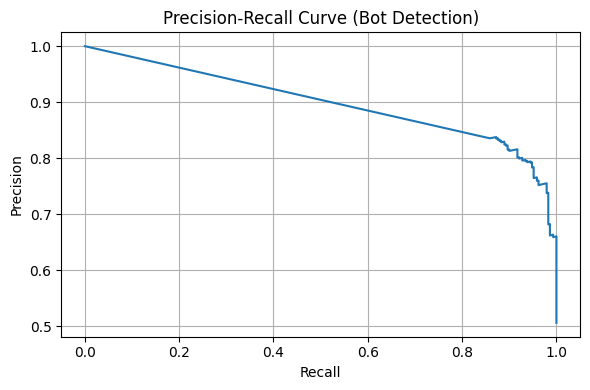

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(val_labels, val_preds)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Bot Detection)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Save model weights
torch.save(model.state_dict(), 'bot_predictor_model.pth')

# Predict on test set
model.eval()
with torch.no_grad():
    test_output = model(X_test_tensor)
    test_prediction = torch.sigmoid(test_output).squeeze().numpy()

In [ ]:
# Save prediction probabilities to submission.csv
submission = pd.DataFrame({
    'bidder_id': df_test['bidder_id'],
    'prediction': np.round(test_prediction, 1)

})
submission.to_csv('submission.csv', index=False)

# Optional: download the file
files.download('submission.csv')

# Check prediction distribution
print(f"Submission file created ✅")
print(f"Prediction probability range: min={test_prediction.min():.4f}, max={test_prediction.max():.4f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Submission file created ✅
Prediction probability range: min=0.0000, max=0.7972
